In [1]:
from google.colab import files
uploaded = files.upload()

Saving weather_classification_data.csv to weather_classification_data.csv


## импорты и загрузка данных

In [4]:
df = pd.read_csv('weather_classification_data.csv')
print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
df.head()

Размер датасета: (13200, 11)

Первые 5 строк:


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


## анализ данных

In [6]:
# Информация о датасете
print("Информация о датасете:")
print(df.info())
print("\nСтатистика:")
print(df.describe())
print("\nКоличество каждого класса погоды:")
print(df['Weather Type'].value_counts())

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB
None

Статистика:
        Temperature      Humidity    Wind Speed  Precipitation (%)  \
count  13200.000000  13200.000000  13200.000000       1

## графики

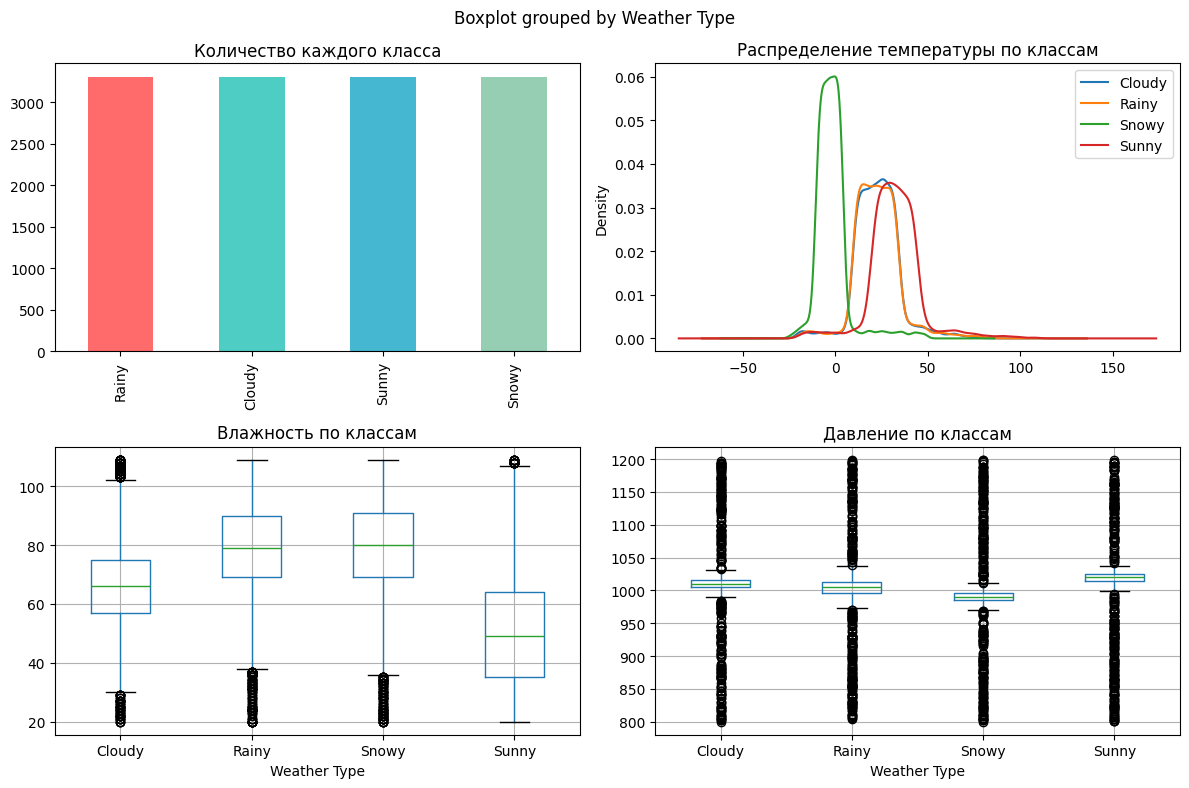

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Анализ данных погоды', fontsize=16)

# Распределение классов
df['Weather Type'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4'])
axes[0,0].set_title('Количество каждого класса')
axes[0,0].set_xlabel('')

# Распределение температуры
df.groupby('Weather Type')['Temperature'].plot(kind='kde', ax=axes[0,1], legend=True)
axes[0,1].set_title('Распределение температуры по классам')

# Распределение влажности
df.boxplot(column='Humidity', by='Weather Type', ax=axes[1,0])
axes[1,0].set_title('Влажность по классам')

# Распределение давления
df.boxplot(column='Atmospheric Pressure', by='Weather Type', ax=axes[1,1])
axes[1,1].set_title('Давление по классам')

plt.tight_layout()
plt.show()

## корреляционная матрица

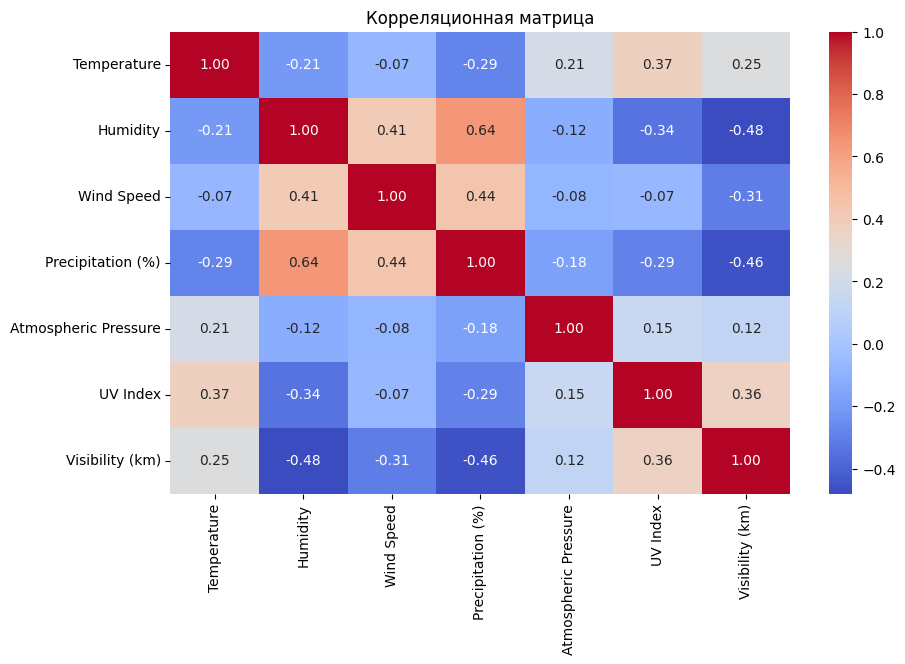

In [8]:
plt.figure(figsize=(10, 6))
numeric_cols = ['Temperature', 'Humidity', 'Wind Speed',
                'Precipitation (%)', 'Atmospheric Pressure',
                'UV Index', 'Visibility (km)']
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

## предобработка данных

In [9]:
# Кодирование категориальных признаков
le_cloud = LabelEncoder()
le_season = LabelEncoder()
le_location = LabelEncoder()
le_target = LabelEncoder()

df['Cloud Cover'] = le_cloud.fit_transform(df['Cloud Cover'])
df['Season'] = le_season.fit_transform(df['Season'])
df['Location'] = le_location.fit_transform(df['Location'])
df['target'] = le_target.fit_transform(df['Weather Type'])

# Признаки и целевая переменная
X = df.drop(['Weather Type', 'target'], axis=1)
y = df['target']

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)
print("Классы:", le_target.classes_)

Размер обучающей выборки: (10560, 10)
Размер тестовой выборки: (2640, 10)
Классы: ['Cloudy' 'Rainy' 'Snowy' 'Sunny']


## обучение моделей

In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

print("\nЛучшая модель:", max(results, key=results.get))

Logistic Regression: 0.8485
KNN: 0.8917
Decision Tree: 0.9061
Random Forest: 0.9102
SVM: 0.9068

Лучшая модель: Random Forest


## детальный анализ лучшей модели

Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.87      0.90      0.88       651
       Rainy       0.91      0.91      0.91       647
       Snowy       0.93      0.94      0.94       701
       Sunny       0.93      0.90      0.91       641

    accuracy                           0.91      2640
   macro avg       0.91      0.91      0.91      2640
weighted avg       0.91      0.91      0.91      2640



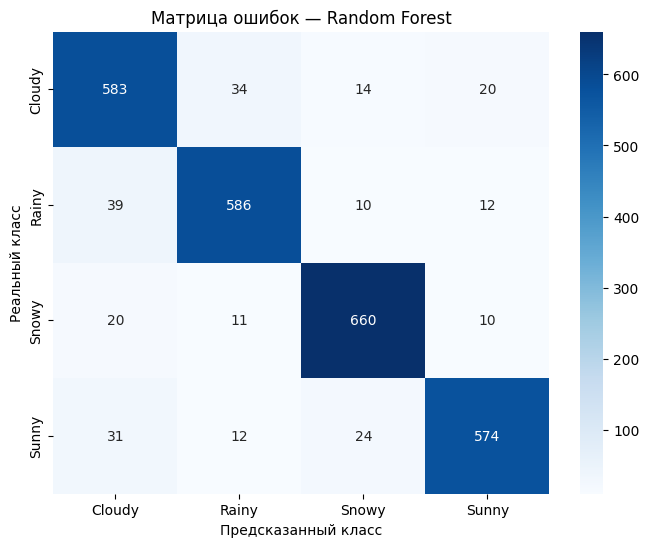

In [12]:
best_model = models['Random Forest']
y_pred = best_model.predict(X_test)

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title('Матрица ошибок — Random Forest')
plt.ylabel('Реальный класс')
plt.xlabel('Предсказанный класс')
plt.show()

## сравнительный график моделей

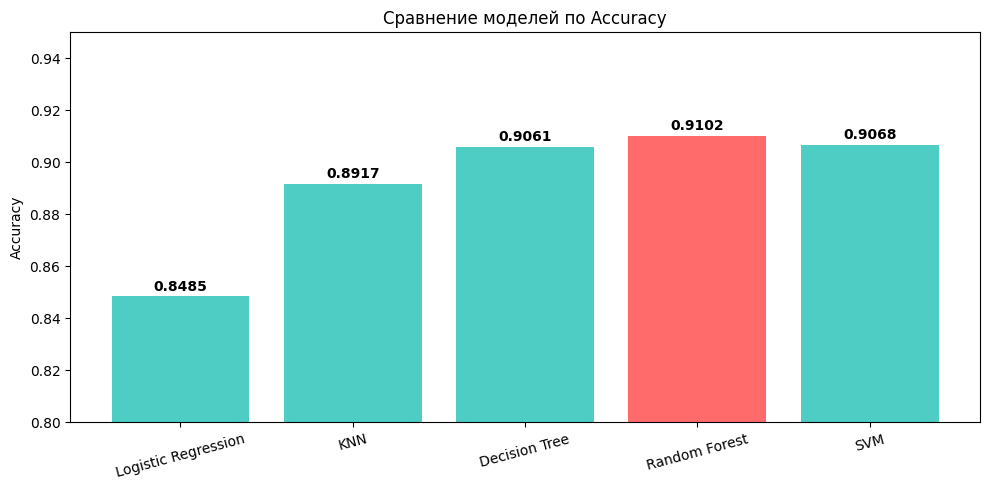

In [13]:
plt.figure(figsize=(10, 5))
colors = ['#FF6B6B' if v == max(results.values()) else '#4ECDC4' for v in results.values()]
bars = plt.bar(results.keys(), results.values(), color=colors)
plt.title('Сравнение моделей по Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0.8, 0.95)
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## сохранение модели

In [14]:
import pickle

# Сохраняем модель и вспомогательные объекты
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le_target, f)

print("Модель сохранена!")

# Скачиваем файлы на компьютер
from google.colab import files
files.download('best_model.pkl')
files.download('scaler.pkl')
files.download('label_encoder.pkl')

Модель сохранена!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>